# 08. Walk-forward con media temporada

El backtest principal re-entrena el modelo una vez por año, en agosto, con los datos hasta mayo anterior. El tutor sugiere probar con media temporada como periodo de test: re-entrenar en agosto Y en enero, usando los datos disponibles en cada momento.

Lo que se gana, en teoría:

- El modelo se adapta más rápido a cosas que cambian a mitad de temporada (lesiones, fichajes de invierno, cambio de entrenador).
- La segunda mitad de la temporada tiene menos incertidumbre (equipos más asentados) y podría ser más predecible.

Mitades:

- H1 (primera vuelta): meses 8-12 (agosto-diciembre).
- H2 (segunda vuelta): meses 1-5 (enero-mayo).

Ventana de entrenamiento: las 5 temporadas previas, igual que el backtest principal del notebook 03 para que sea comparable.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import log_loss, accuracy_score
import matplotlib.pyplot as plt

DATA_PATH    = '../data/df_final_clean.csv'
TRAIN_WINDOW = 5          # ultimas 5 temporadas completas como train
FIRST_TEST   = 2012       # primera temporada de test
FEATURES = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5',
    'Home_H2H_L3','Away_H2H_L3',
]
ODDS_FILTER  = [('1',1.40,1.70),('1',2.00,2.50)]
import json
with open('../results/best_params.json') as _f:
    _bp = json.load(_f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3, 'eval_metric':'mlogloss',
              'random_state':42, 'verbosity':0, 'n_jobs':-1}
INIT_BK      = 1000.0
FLAT_STAKE   = 10.0
MIN_EV       = 0.05
KILL_MIN     = 15
KILL_THR     = 0.08

# Meses de cada mitad de temporada
H1_MONTHS = [8, 9, 10, 11, 12]   # agosto - diciembre
H2_MONTHS = [1, 2, 3, 4, 5]      # enero  - mayo

def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
df['Month'] = df['Date'].dt.month
# Identificar mitad de temporada
df['Half'] = df['Month'].apply(lambda m: 'H1' if m in H1_MONTHS else 'H2')
df['Period'] = df['Season'].astype(str) + '-' + df['Half']  # ej: '2015-H1'
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])

all_seasons = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]

print(f'Dataset: {len(df)} partidos')
print(f'Temporadas test: {test_seasons}')
print(f'Partidos por mitad:')
print(df.groupby('Half').size().to_string())

Dataset: 5700 partidos
Temporadas test: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Partidos por mitad:
Half
H1    2513
H2    3187


## Walk-forward con temporada completa (baseline)

Mismo setup que el notebook 03 para tener referencia directa.

In [2]:
def kelly_stake(p, odds, frac=0.25, cap=0.05, bk=INIT_BK):
    return max(0.0, min((p*odds-1)/(odds-1)*frac, cap)) * bk

def run_full_season():
    """Walk-forward con test de 1 temporada completa."""
    all_bets, period_rows = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior[-TRAIN_WINDOW:]
        if not tr_s: continue

        tr = df['Season'].isin(tr_s)
        te = df['Season'] == test_s
        X_tr, y_tr = df.loc[tr, FEATURES].values, df.loc[tr,'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS), method='isotonic', cv=TimeSeriesSplit(n_splits=3))
        model.fit(X_tr, y_tr)
        proba   = model.predict_proba(df_te[FEATURES].values)
        classes = list(model.classes_)
        p_H = proba[:, classes.index(2)]
        p_D = proba[:, classes.index(1)]
        p_A = proba[:, classes.index(0)]

        bets = []; killed = False
        for i, row in df_te.iterrows():
            if killed: break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= MIN_EV: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                bets.append({'Period':f'{test_s}-Full','Season':test_s,
                             'P_Model':p,'Won':won,
                             'Flat_P':FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                             'Flat_S':FLAT_STAKE})
            if len(bets) >= KILL_MIN:
                obs = np.mean([b['Won'] for b in bets])
                exp = np.mean([b['P_Model'] for b in bets])
                if obs < exp - KILL_THR: killed = True

        if bets:
            b  = pd.DataFrame(bets)
            fr = b['Flat_P'].sum() / b['Flat_S'].sum()
            period_rows.append({'Period':f'{test_s}-Full','Season':test_s,'Half':'Full',
                                'N_Bets':len(b),'Hit_Rate':round(b['Won'].mean(),3),
                                'Flat_ROI':round(fr,4),'Flat_PnL':round(b['Flat_P'].sum(),2)})
            all_bets.extend(bets)

    return pd.DataFrame(all_bets), pd.DataFrame(period_rows)

print('Ejecutando full-season...')
bets_full, seasons_full = run_full_season()
roi_full = bets_full['Flat_P'].sum() / bets_full['Flat_S'].sum()
pos_full = (seasons_full['Flat_ROI'] > 0).sum()
print(f'Full-season: {len(bets_full)} bets | ROI {roi_full*100:+.2f}% | '
      f'BK {INIT_BK+bets_full["Flat_P"].sum():.0f} EUR | Pos {pos_full}/{len(seasons_full)}')
print(seasons_full[['Season','N_Bets','Hit_Rate','Flat_ROI']].to_string(index=False))

Ejecutando full-season...
Full-season: 344 bets | ROI +2.59% | BK 1089 EUR | Pos 5/13
 Season  N_Bets  Hit_Rate  Flat_ROI
   2012      60     0.567    0.1618
   2013      45     0.467    0.0247
   2014      15     0.533   -0.0327
   2015      15     0.467   -0.1613
   2016      30     0.667    0.2063
   2017      65     0.600    0.1428
   2018      15     0.400   -0.1887
   2019      15     0.267   -0.5200
   2020      20     0.550   -0.0310
   2021      15     0.600   -0.0620
   2022      15     0.333   -0.4320
   2023      15     0.467   -0.0787
   2024      19     0.632    0.2821


## Walk-forward con media temporada

Re-entreno dos veces por temporada:

- Antes de H1 (agosto): entreno con las 5 temporadas anteriores.
- Antes de H2 (enero): entreno con las 5 temporadas anteriores + el H1 de la temporada actual.

Así el modelo de H2 ya incorpora los partidos de la primera vuelta antes de predecir la segunda.

In [3]:
def run_half_season():
    """Walk-forward con test de media temporada (H1 y H2 por separado)."""
    all_bets, period_rows = [], []

    for test_s in test_seasons:
        prior_seasons = [s for s in all_seasons if s < test_s]
        tr_s = prior_seasons[-TRAIN_WINDOW:]
        if not tr_s: continue

        for half in ['H1', 'H2']:
            # Train: ultimas 5 temporadas completas
            # Para H2: tambien incluir H1 de la temporada actual como train adicional
            tr_mask = df['Season'].isin(tr_s)
            if half == 'H2':
                # Incluir H1 del año de test en el train
                h1_mask = (df['Season'] == test_s) & (df['Half'] == 'H1')
                tr_mask = tr_mask | h1_mask

            te_mask = (df['Season'] == test_s) & (df['Half'] == half)
            X_tr = df.loc[tr_mask, FEATURES].values
            y_tr = df.loc[tr_mask, 'Target'].values
            df_te = df[te_mask].reset_index(drop=True)

            if len(X_tr) < 50 or len(df_te) == 0: continue

            model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS), method='isotonic', cv=TimeSeriesSplit(n_splits=3))
            model.fit(X_tr, y_tr)
            proba   = model.predict_proba(df_te[FEATURES].values)
            classes = list(model.classes_)
            p_H = proba[:, classes.index(2)]
            p_D = proba[:, classes.index(1)]
            p_A = proba[:, classes.index(0)]

            bets = []; killed = False
            for i, row in df_te.iterrows():
                if killed: break
                oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
                if oh < 1.05 or od < 1.05 or oa < 1.05: continue
                ftr = str(row['FTR'])
                for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                          ('X',p_D[i],od,ftr=='D'),
                                          ('2',p_A[i],oa,ftr=='A')]:
                    ev = p * odds - 1
                    if ev <= MIN_EV: continue
                    if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                    bets.append({'Period':f'{test_s}-{half}','Season':test_s,'Half':half,
                                 'P_Model':p,'Won':won,
                                 'Flat_P':FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                                 'Flat_S':FLAT_STAKE})
                if len(bets) >= KILL_MIN:
                    obs = np.mean([b['Won'] for b in bets])
                    exp = np.mean([b['P_Model'] for b in bets])
                    if obs < exp - KILL_THR: killed = True

            if bets:
                b  = pd.DataFrame(bets)
                fr = b['Flat_P'].sum() / b['Flat_S'].sum()
                period_rows.append({'Period':f'{test_s}-{half}','Season':test_s,'Half':half,
                                    'N_Bets':len(b),'Hit_Rate':round(b['Won'].mean(),3),
                                    'Flat_ROI':round(fr,4),'Flat_PnL':round(b['Flat_P'].sum(),2)})
                all_bets.extend(bets)

    return pd.DataFrame(all_bets), pd.DataFrame(period_rows)

print('Ejecutando half-season...')
bets_half, periods_half = run_half_season()
roi_half = bets_half['Flat_P'].sum() / bets_half['Flat_S'].sum()
pos_half = (periods_half['Flat_ROI'] > 0).sum()
print(f'Half-season: {len(bets_half)} bets | ROI {roi_half*100:+.2f}% | '
      f'BK {INIT_BK+bets_half["Flat_P"].sum():.0f} EUR | Pos {pos_half}/{len(periods_half)} periodos')
print()
print(periods_half[['Period','N_Bets','Hit_Rate','Flat_ROI','Flat_PnL']].to_string(index=False))

Ejecutando half-season...
Half-season: 463 bets | ROI -0.37% | BK 983 EUR | Pos 11/26 periodos

 Period  N_Bets  Hit_Rate  Flat_ROI  Flat_PnL
2012-H1      30     0.600    0.2367      71.0
2012-H2      25     0.440   -0.0632     -15.8
2013-H1      18     0.556    0.2117      38.1
2013-H2      20     0.450   -0.0375      -7.5
2014-H1      13     0.538   -0.0123      -1.6
2014-H2      17     0.647    0.2288      38.9
2015-H1      15     0.467   -0.1613     -24.2
2015-H2      21     0.619    0.1052      22.1
2016-H1      11     0.727    0.3218      35.4
2016-H2      21     0.571    0.0762      16.0
2017-H1      30     0.667    0.2657      79.7
2017-H2      24     0.542    0.0558      13.4
2018-H1      15     0.400   -0.1887     -28.3
2018-H2      15     0.400   -0.2413     -36.2
2019-H1      15     0.267   -0.5200     -78.0
2019-H2      15     0.467   -0.1360     -20.4
2020-H1      20     0.550   -0.0310      -6.2
2020-H2      15     0.467   -0.2107     -31.6
2021-H1      15     0.600   -0

## H1 vs H2

In [4]:
for half in ['H1', 'H2']:
    sub = bets_half[bets_half['Half'] == half]
    if len(sub) == 0: continue
    roi = sub['Flat_P'].sum() / sub['Flat_S'].sum()
    pos = (periods_half[periods_half['Half']==half]['Flat_ROI'] > 0).sum()
    total = (periods_half['Half']==half).sum()
    print(f'{half}: {len(sub):3} bets | Hit {sub["Won"].mean():.1%} | '
          f'ROI {roi*100:+.2f}% | Pos {pos}/{total} periodos')

H1: 217 bets | Hit 53.0% | ROI +0.54% | Pos 5/13 periodos
H2: 246 bets | Hit 52.8% | ROI -1.16% | Pos 6/13 periodos


## Comparativa Full vs Half

In [5]:
print('=' * 60)
print(f'{"":30} {"Full":>12} {"Half":>12}')
print('-' * 60)

roi_f  = bets_full['Flat_P'].sum() / bets_full['Flat_S'].sum()
roi_h  = bets_half['Flat_P'].sum() / bets_half['Flat_S'].sum()
bk_f   = INIT_BK + bets_full['Flat_P'].sum()
bk_h   = INIT_BK + bets_half['Flat_P'].sum()
pos_f  = (seasons_full['Flat_ROI'] > 0).sum()
pos_h  = (periods_half.groupby('Season')['Flat_PnL'].sum() > 0).sum()
n_s_f  = len(seasons_full)
n_s_h  = periods_half['Season'].nunique()
hit_f  = bets_full['Won'].mean()
hit_h  = bets_half['Won'].mean()

print(f'{"Total apuestas":30} {len(bets_full):>12} {len(bets_half):>12}')
print(f'{"Flat ROI":30} {roi_f*100:>+11.2f}% {roi_h*100:>+11.2f}%')
print(f'{"BK final (EUR)":30} {bk_f:>12.0f} {bk_h:>12.0f}')
print(f'{"Hit rate":30} {hit_f:>12.1%} {hit_h:>12.1%}')
print(f'{"Temporadas positivas":30} {pos_f:>5}/{n_s_f:<6} {pos_h:>5}/{n_s_h:<6}')
print('=' * 60)

# ROI por temporada (agregando H1+H2 en half)
print()
print('ROI por temporada:')
season_roi_half = periods_half.groupby('Season').apply(
    lambda g: round(g['Flat_PnL'].sum() / (g['N_Bets'].sum() * FLAT_STAKE), 4),
    include_groups=False
).reset_index()
season_roi_half.columns = ['Season', 'ROI_Half']

comp = seasons_full[['Season','N_Bets','Flat_ROI']].copy()
comp.columns = ['Season','Bets_Full','ROI_Full']
comp = comp.merge(season_roi_half, on='Season', how='outer')
print(comp.to_string(index=False))

                                       Full         Half
------------------------------------------------------------
Total apuestas                          344          463
Flat ROI                             +2.59%       -0.37%
BK final (EUR)                         1089          983
Hit rate                              53.2%        52.9%
Temporadas positivas               5/13         6/13    

ROI por temporada:
 Season  Bets_Full  ROI_Full  ROI_Half
   2012         60    0.1618    0.1004
   2013         45    0.0247    0.0805
   2014         15   -0.0327    0.1243
   2015         15   -0.1613   -0.0058
   2016         30    0.2063    0.1606
   2017         65    0.1428    0.1724
   2018         15   -0.1887   -0.2150
   2019         15   -0.5200   -0.3280
   2020         20   -0.0310   -0.1080
   2021         15   -0.0620   -0.0361
   2022         15   -0.4320   -0.2497
   2023         15   -0.0787   -0.0687
   2024         19    0.2821    0.1135


## Visualización

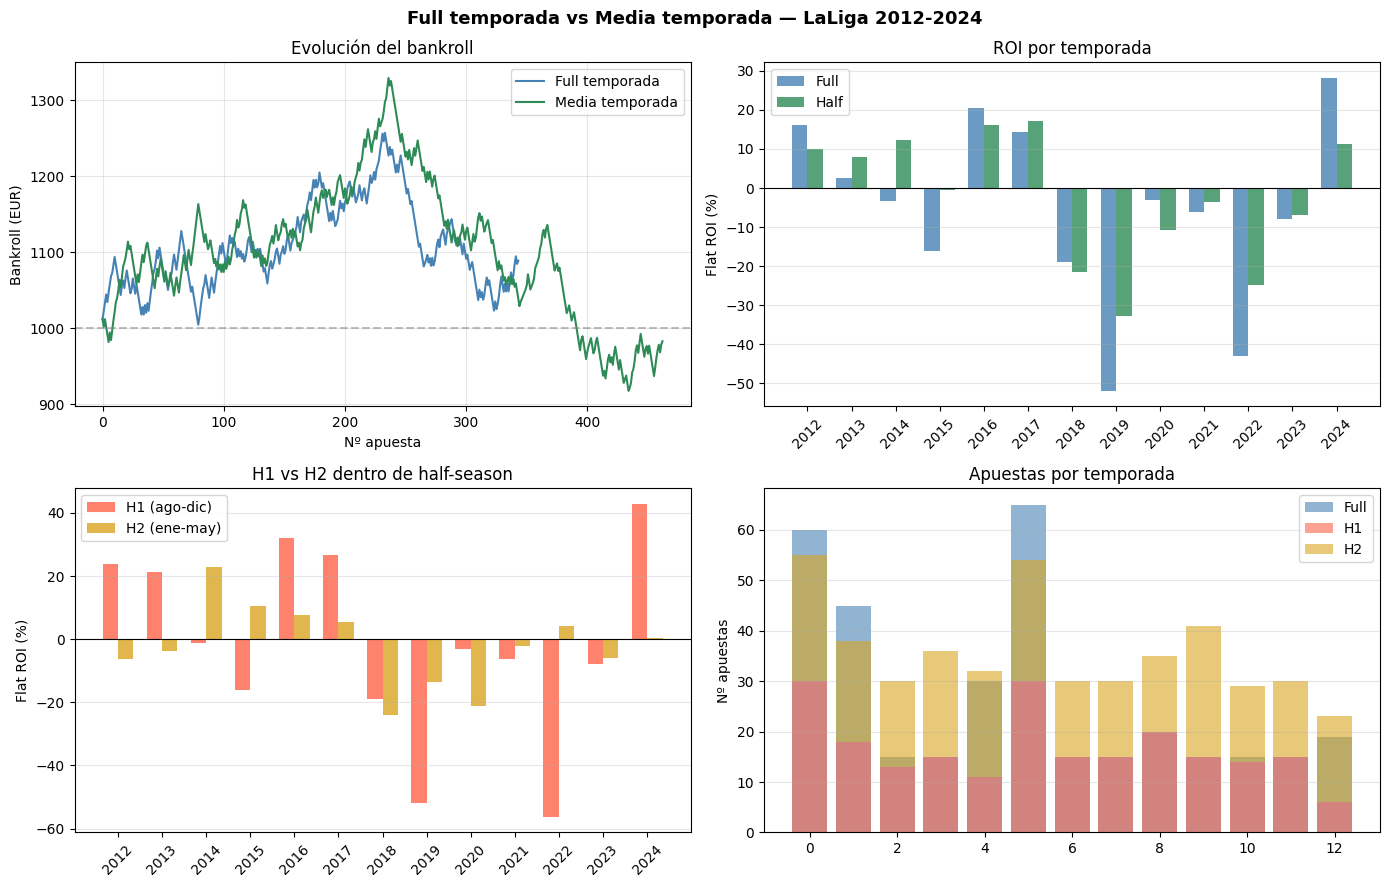

Guardado: results/media_temporada.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Bankroll comparativo
bets_full_sorted = bets_full.sort_values('Period')
bets_half_sorted = bets_half.sort_values(['Season','Half'])
bk_full = INIT_BK + bets_full_sorted['Flat_P'].cumsum()
bk_half = INIT_BK + bets_half_sorted['Flat_P'].cumsum()

axes[0,0].plot(range(len(bk_full)), bk_full.values, color='steelblue', label='Full temporada')
axes[0,0].plot(range(len(bk_half)), bk_half.values, color='seagreen',  label='Media temporada')
axes[0,0].axhline(INIT_BK, color='gray', linestyle='--', alpha=0.5)
axes[0,0].set_xlabel('Nº apuesta'); axes[0,0].set_ylabel('Bankroll (EUR)')
axes[0,0].set_title('Evolución del bankroll'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# 2. ROI por temporada
seasons_plot = sorted(comp['Season'].dropna().astype(int).unique())
x = range(len(seasons_plot))
w = 0.35
rois_full = [comp.loc[comp['Season']==s,'ROI_Full'].values[0]
             if s in comp['Season'].values else 0 for s in seasons_plot]
rois_half = [comp.loc[comp['Season']==s,'ROI_Half'].values[0]
             if s in comp['Season'].values else 0 for s in seasons_plot]
axes[0,1].bar([i-w/2 for i in x], [r*100 for r in rois_full], w,
              color='steelblue', alpha=0.8, label='Full')
axes[0,1].bar([i+w/2 for i in x], [r*100 for r in rois_half], w,
              color='seagreen', alpha=0.8, label='Half')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(seasons_plot, rotation=45)
axes[0,1].set_ylabel('Flat ROI (%)'); axes[0,1].set_title('ROI por temporada')
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.3)

# 3. H1 vs H2 en half-season
h1_rois = periods_half[periods_half['Half']=='H1']['Flat_ROI'].values
h2_rois = periods_half[periods_half['Half']=='H2']['Flat_ROI'].values
h1_seasons = periods_half[periods_half['Half']=='H1']['Season'].values
h2_seasons = periods_half[periods_half['Half']=='H2']['Season'].values
axes[1,0].bar([i-w/2 for i in range(len(h1_rois))], h1_rois*100, w,
              color='tomato', alpha=0.8, label='H1 (ago-dic)')
axes[1,0].bar([i+w/2 for i in range(len(h2_rois))], h2_rois*100, w,
              color='goldenrod', alpha=0.8, label='H2 (ene-may)')
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(range(len(h1_seasons)))
axes[1,0].set_xticklabels(h1_seasons, rotation=45)
axes[1,0].set_ylabel('Flat ROI (%)'); axes[1,0].set_title('H1 vs H2 dentro de half-season')
axes[1,0].legend(); axes[1,0].grid(axis='y', alpha=0.3)

# 4. Nº apuestas por periodo
n_full = seasons_full['N_Bets'].values
n_h1   = periods_half[periods_half['Half']=='H1']['N_Bets'].values
n_h2   = periods_half[periods_half['Half']=='H2']['N_Bets'].values
axes[1,1].bar(range(len(n_full)), n_full, color='steelblue', alpha=0.6, label='Full')
axes[1,1].bar(range(len(n_h1)), n_h1, color='tomato', alpha=0.6, label='H1')
axes[1,1].bar(range(len(n_h2)), n_h2, color='goldenrod', alpha=0.6,
              bottom=n_h1[:len(n_h2)], label='H2')
axes[1,1].set_ylabel('Nº apuestas'); axes[1,1].set_title('Apuestas por temporada')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Full temporada vs Media temporada — LaLiga 2012-2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/media_temporada.png', dpi=120, bbox_inches='tight')
plt.show()

# Guardar
periods_half.to_csv('../results/half_season_periods.csv', index=False)
comp.to_csv('../results/full_vs_half_comparison.csv', index=False)
print('Guardado: results/media_temporada.png')

## Conclusiones

### Re-entrenar a mitad de temporada, ¿mejora el ROI?

En agregado no, pero en consistencia per-season un poco sí. Full-season da +2.59% ROI (344 bets, 5/13 temporadas, BK 1089 EUR). Half-season da -0.37% (463 bets, 11/26 periodos positivos, BK 983 EUR). Half añade unas 119 apuestas más, con peor edge medio, lo que arrastra el ROI agregado casi 3 pp por debajo. La parte buena es que half mejora a full en 6 de 13 temporadas, sobre todo en años malos: 2014 (+15.7 pp), 2015 (+15.5 pp), 2019 (+19.2 pp), 2022 (+18.2 pp).

### ¿Es la H2 más predecible que la H1?

H1 marginalmente sí, pero ambas están cerca de cero. H1 (agosto-diciembre): +0.54% ROI (217 bets, hit 53.0%, 5/13 periodos positivos). H2 (enero-mayo): -1.16% ROI (246 bets, hit 52.8%, 6/13). H1 saca yield ligeramente positivo y H2 ligeramente negativo, aunque H2 acierta una temporada más por bet. La diferencia es pequeña y entra en el IC del 0 con esta muestra (~220 bets cada mitad).

Lo que sí queda claro es que la intuición "la segunda vuelta es más predecible porque los equipos están más asentados" no se cumple en estos datos. Las lesiones de invierno, fichajes de enero y cambios de entrenador parecen meter ruido suficiente como para que H2 no rinda mejor que H1.

### ¿Vale la pena meter el half-season?

No para reemplazar al full-season. La pérdida de 3 pp en ROI agregado (+2.59% → -0.37%) no compensa la mejora en consistencia per-season. La complejidad añadida tampoco es trivial: doble entrenamiento por temporada, lógica de fechas, recompute del Elo dos veces. Y el grueso de la mejora se concentra en años malos donde el kill switch corta full a 15 apuestas; half permite re-empezar tras la pausa de invierno y limita un poco el daño, pero no captura un patrón estructural.

### ROI por temporada (full vs half)

| Año | Full | Half | Δ (Half - Full) |
|------|---|---|---|
| 2012 | +16.18% | +10.04% | -6.14 |
| 2013 | +2.47% | +8.05% | +5.58 |
| 2014 | -3.27% | +12.43% | **+15.70** |
| 2015 | -16.13% | -0.58% | **+15.55** |
| 2016 | +20.63% | +16.06% | -4.57 |
| 2017 | +14.28% | +17.24% | +2.96 |
| 2018 | -18.87% | -21.50% | -2.63 |
| 2019 | -52.00% | -32.80% | **+19.20** |
| 2020 | -3.10% | -10.80% | -7.70 |
| 2021 | -6.20% | -3.61% | +2.59 |
| 2022 | -43.20% | -24.97% | **+18.23** |
| 2023 | -7.87% | -6.87% | +1.00 |
| 2024 | +28.21% | +11.35% | -16.86 |

Half ayuda más cuando full lo tiene muy mal (2014, 2015, 2019, 2022). Empata o pierde poco en años neutros. La excepción notable es 2024: full saca +28.21% y half se queda en +11.35%; aquí el modelo de H1 estaba acertando muy bien y meter el de H2 lo descuadró.